# SpecklePattern
## Tracking a moving object
### Run on kernel "Python [conda env:base]"

In [1]:
import numpy as np
import matplotlib.pyplot as py
import imageio.v3 as image

In [2]:
dimensions = 512 # dimensions refers to the length of one side of the speckle pattern (speckle pattern is a square)
padding = 400
halfpadding = int(np.round(padding/2))

In [3]:
# Split matrix up into sections to optimise gaussian production

sectionsizeTLx = []
sectionsizeTLy = []
sectionsizeBRx = []
sectionsizeBRy = []
section = dimensions/(64)
nosections = int((dimensions/section)**2)
print(nosections)
xpos = 0
ypos = 0
for i in range(nosections-1):
    if xpos < dimensions-section:
        sectionsizeTLx.append(xpos)
        sectionsizeTLy.append(ypos)
        sectionsizeBRx.append(xpos+section)
        sectionsizeBRy.append(ypos+section)
        xpos += section
    else:
        sectionsizeTLx.append(xpos)
        sectionsizeTLy.append(ypos)
        sectionsizeBRx.append(xpos+section)
        sectionsizeBRy.append(ypos+section)
        xpos = 0
        ypos += section

print(len(sectionsizeTLx))

4096
4095


In [4]:
# Gaussian Point
def GaussPoint(position,variance):
    # Gaussian Point
    # Inputs:
    # position - Input an array containing the x and y position of the object respectively
    # variance - Determines the width of the gaussian point
    #
    # Outputs:
    # gaussian - matrix containing the gaussian point

    usedsectionsizeTLx = []
    usedsectionsizeTLy = []
    #print(10*variance)
    maxgauss = 1
    #print(position[0])
    #print(position[1])
    enclosedsection = 0
    for i in range(nosections-1):
        #if ((position[1] - sectionsizeTLx[i])**2 + (position[0] - sectionsizeTLy[i])**2)**0.5 < 10*variance or ((position[1] - sectionsizeBRx[i])**2 + (position[0] - sectionsizeBRy[i])**2)**0.5 < 10*variance:
        if abs(position[0] - sectionsizeTLx[i]) <= 10*variance and abs(position[1] - sectionsizeTLy[i]) <= 10*variance and abs(position[0] - sectionsizeBRx[i]) <= 10*variance and abs(position[1] - sectionsizeBRy[i]) <= 10*variance:    
            usedsectionsizeTLx.append(sectionsizeTLx[i])
            usedsectionsizeTLy.append(sectionsizeTLy[i])
            #print(usedsectionsizeTLy[i])
        #print(str(position[0]) + "  " +  str(sectionsizeTLx[i]) + "    " + str(position[1]) + "  " +  str(sectionsizeTLy[i]))
        if position[0] >= sectionsizeTLx[i] and position[1] >= sectionsizeTLy[i] and position[0] < (sectionsizeTLx[i]+section) and position[1] < (sectionsizeTLy[i]+section):
            enclosedsection = i
            
    if len(usedsectionsizeTLx) == 0:
        usedsectionsizeTLx.append(sectionsizeTLx[enclosedsection])
        usedsectionsizeTLy.append(sectionsizeTLy[enclosedsection])
        
    #print(len(usedsectionsizeTLx))
    gaussian = np.empty((dimensions,dimensions)) # Create an empty matrix the size of the speckle pattern

    #print(len(usedsectionsizeTLx))
    #print(len(usedsectionsizeTLy))
    
    xcoord = 0
    ycoord = 0
    for i in range(len(usedsectionsizeTLx)):
        xcoord = int(usedsectionsizeTLx[i])
        ycoord = int(usedsectionsizeTLy[i])
        #print(usedsectionsizeTLy[i])
        #print(usedsectionsizeTLy[i])
        for j in range(int((section**2))):
            #print(str(xcoord) + "  " +  str(ycoord))
            if xcoord < dimensions:
                gaussian[xcoord,ycoord] = ((1/(2*np.pi*variance**2))*np.exp(-((xcoord-position[0])**2)/(2*variance**2)) * (1/(2*np.pi*variance**2))*np.exp(-((ycoord-position[1])**2)/(2*variance**2)))/2
                xcoord += 1
            if xcoord == int(usedsectionsizeTLx[i] + section) or xcoord >= dimensions:
                xcoord = int(usedsectionsizeTLx[i])
                ycoord += 1
            #else:
            #    xcoord += 1
#    py.scatter(usedsectionsizeTLx,usedsectionsizeTLy)
#        
#
#    for i in range(dimensions**2): # Repeat the following for each item in the speckle pattern
#        ycoord = int(np.trunc(i/dimensions)) # Find the x and y coordinates of the current item
#        xcoord = int(i - ycoord*dimensions)
#        
#        # Produce a gaussian around the specified point as the product of gaussian curves in the x and y directions
#        if ((position[1] - xcoord)**2 + (position[0] - ycoord)**2)**0.5 > 10*variance:
#            gaussian[xcoord,ycoord] = 0
#        else:
#            gaussian[xcoord,ycoord] = ((1/(2*np.pi*variance**2))*np.exp(-((xcoord-position[1])**2)/(2*variance**2)) * (1/(2*np.pi*variance**2))*np.exp(-((ycoord-position[0])**2)/(2*variance**2)))/2
#        
#        if gaussian[xcoord,ycoord] > maxgauss: # Ensure the gaussians maximum value is 1
#            maxgauss = gaussian[xcoord,ycoord]
#
#    gaussian = gaussian/maxgauss
    return gaussian 

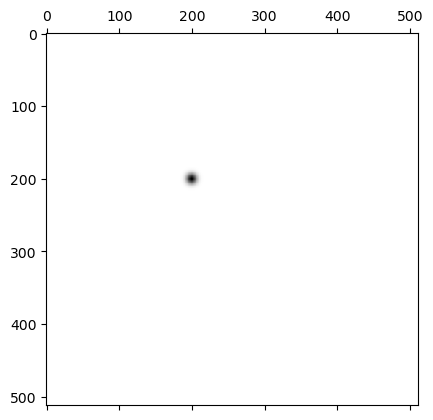

In [99]:
# Object: background (static)

backobjects = 0

# Add gaussian point as objects to image
backobjects += GaussPoint((200,200),5) 

py.matshow(backobjects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_1dot.pdf", format="pdf")

In [43]:
# Gaussian Point
def GaussPoint(position,variance):
    # Gaussian Point
    # Inputs:
    # position - Input an array containing the x and y position of the object respectively
    # variance - Determines the width of the gaussian point
    #
    # Outputs:
    # gaussian - matrix containing the gaussian point
    
    maxgauss = 1
    section = dimensions/(64)
    nosections = (np.round((2*10*variance)/64))**2 
    for i in range(nosections):
        
    gaussian = np.empty((dimensions,dimensions)) # Create an empty matrix the size of the speckle pattern

    for i in range(dimensions**2): # Repeat the following for each item in the speckle pattern
        ycoord = int(np.trunc(i/dimensions)) # Find the x and y coordinates of the current item
        xcoord = int(i - ycoord*dimensions)
        
        # Produce a gaussian around the specified point as the product of gaussian curves in the x and y directions
        if ((position[1] - xcoord)**2 + (position[0] - ycoord)**2)**0.5 > 10*variance:
            gaussian[xcoord,ycoord] = 0
        else:
            gaussian[xcoord,ycoord] = ((1/(2*np.pi*variance**2))*np.exp(-((xcoord-position[1])**2)/(2*variance**2)) * (1/(2*np.pi*variance**2))*np.exp(-((ycoord-position[0])**2)/(2*variance**2)))/2
        
        if gaussian[xcoord,ycoord] > maxgauss: # Ensure the gaussians maximum value is 1
            maxgauss = gaussian[xcoord,ycoord]

    gaussian = gaussian/maxgauss
    return gaussian 

IndentationError: expected an indented block after 'for' statement on line 14 (3028484220.py, line 15)

In [5]:
# Form random complex speckle pattern

Rspeckle = np.random.randint(low=-1, high=2, size=(dimensions-padding,dimensions-padding)) # Produce a speckle pattern made of random real
Ispeckle = np.random.randint(low=-1, high=2, size=(dimensions-padding,dimensions-padding)) # and imaginary values from 0 to 1 and combine
speckle = Ispeckle.astype(np.complex64)                      # to make a complex speckle pattern

for i in range((dimensions-padding)**2):
    ycoord = int(np.trunc(i/(dimensions-padding)))
    xcoord = int(i - ycoord*(dimensions-padding))
    speckle[xcoord,ycoord] = np.complex64(Rspeckle[xcoord,ycoord], Ispeckle[xcoord,ycoord])

In [6]:
speckle = np.pad(speckle, (halfpadding, halfpadding))

In [7]:
Fspeckle = np.fft.fft2(speckle) # Perform a Fourier transform on the speckle pattern
#Fspeckle[0,0] = 0.+0.j # Singular pixle in corner was eroniously large, resulting in poor plot

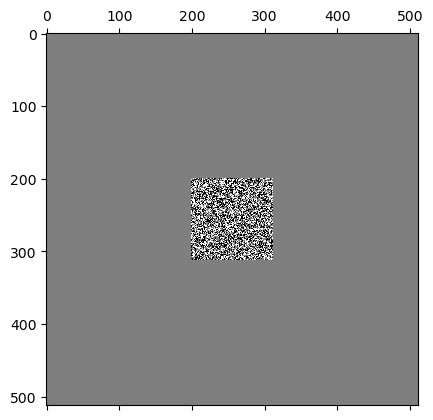

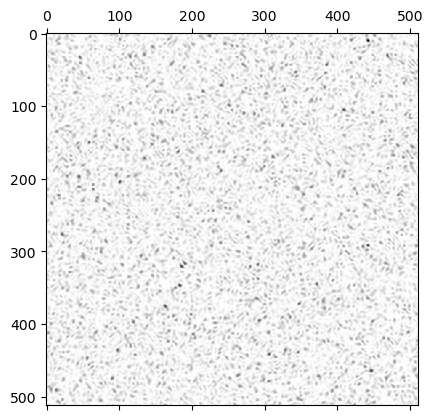

In [8]:
py.matshow((np.real(speckle)), fignum=None, cmap="binary") # Plot the speckle pattern
#py.savefig("Speckle_raw.pdf", format="pdf")
py.matshow((np.abs(Fspeckle)**2), fignum=None, cmap="binary") # Plot the Fourier transform

In [9]:
Fspeckle = Fspeckle #(np.abs(Fspeckle)**2)*GaussPoint((dimensions/2,dimensions/2),60) # Overlay a gaussian surface over
                                                                                 # the speckle pattern
mean = Fspeckle.mean() # Find the mean value of the new speckle pattern

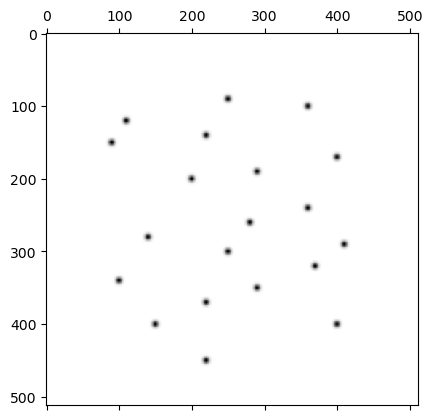

In [10]:
# Object: background (static)

backobjects = 0

# Add gaussian point as objects to image
backobjects += GaussPoint((200,200),3) 
backobjects += GaussPoint((300,250),3)
backobjects += GaussPoint((450,220),3)
backobjects += GaussPoint((290,410),3)
backobjects += GaussPoint((400,150),3)
backobjects += GaussPoint((400,400),3)
backobjects += GaussPoint((350,290),3)
backobjects += GaussPoint((240,360),3)
backobjects += GaussPoint((140,220),3)
backobjects += GaussPoint((340,100),3)

backobjects += GaussPoint((100,360),3)
backobjects += GaussPoint((90,250),3)
backobjects += GaussPoint((190,290),3)
backobjects += GaussPoint((150,90),3)
backobjects += GaussPoint((120,110),3)
backobjects += GaussPoint((280,140),3)
backobjects += GaussPoint((260,280),3)
backobjects += GaussPoint((370,220),3)
backobjects += GaussPoint((170,400),3)
backobjects += GaussPoint((320,370),3)
py.matshow(backobjects, fignum=None, cmap="binary") # Plot objects
#py.savefig("Object_1dot.pdf", format="pdf")

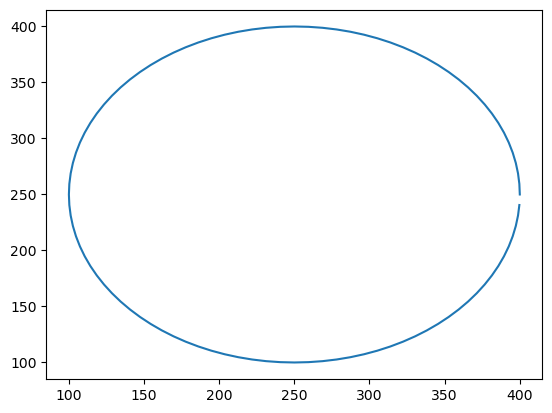

In [11]:
# Object: Moving dot path (circle)

xframeCirc = []
yframeCirc = []
thetaframe = []

noframes = 100
circleradius = 150
xcentre = 250
ycentre = 250

framewidth = 360/noframes
theta = 0
for i in range(noframes):
    xframeCirc.append(circleradius*np.cos(theta*(np.pi/180)) + xcentre)
    yframeCirc.append(circleradius*np.sin(theta*(np.pi/180)) + ycentre)
    theta += framewidth

py.plot(xframeCirc,yframeCirc)

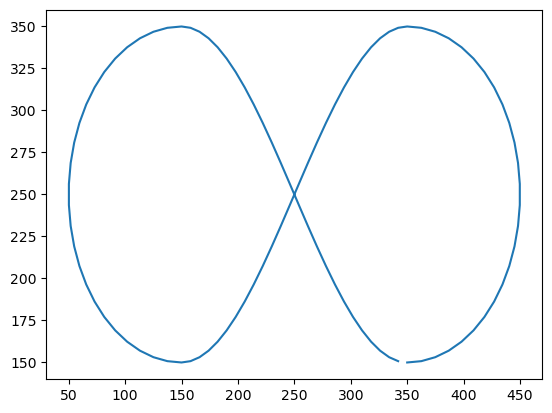

In [12]:
# Object: Moving dot path (Figure of eight) # maybe do in cartesian

xframeCurve = []
yframeCurve = []
thetaframe = []

noframes = 100
width = 400
curveradius = width/4
xcentre = 250
ycentre = 250

#framewidth = 360/noframes
#theta = 0
#for i in range(noframes):
#    sqrradius = (size**2)*np.cos(2*theta)*(1/np.cos(theta))**4
#    #print(sqrradius)
#    xframe.append((sqrradius**0.5)*np.cos(theta*(np.pi/180)) + xcentre)
#    yframe.append((sqrradius**0.5)*np.sin(theta*(np.pi/180)) + ycentre)
#    theta += framewidth
framewidth = 180/noframes
circletheta = 0
sinexval = xcentre + width/2 - curveradius 
sineyval = ycentre + curveradius

for i in range(int(noframes)):
    if i < int(noframes/4):
        xframeCurve.append(curveradius*np.cos((circletheta-90)*(np.pi/180)) + xcentre + width/2 - curveradius)
        yframeCurve.append(curveradius*np.sin((circletheta-90)*(np.pi/180)) + ycentre)
        circletheta += 4*framewidth
    elif i < int(noframes/2):
        xframeCurve.append(sinexval)
        yframeCurve.append(curveradius*np.sin((1/(2*curveradius))*np.pi*(sinexval - xcentre)) + ycentre)
        sinexval -= (width-2*curveradius)/(noframes/4)
    elif i < int(3*noframes/4):
        xframeCurve.append(curveradius*np.cos((circletheta+90)*(np.pi/180)) + xcentre - width/2 + curveradius)
        yframeCurve.append(curveradius*np.sin((circletheta+90)*(np.pi/180)) + ycentre)
        circletheta -= 4*framewidth
    elif i < int(noframes):
        xframeCurve.append(sinexval)
        #yframe.append(np.sin(curveradius*(sinexval - xcentre)) + ycentre)
        yframeCurve.append(curveradius*np.sin((1/(2*curveradius))*np.pi*(sinexval + width/2 - xcentre)) + ycentre) 
        sinexval += (width-2*curveradius)/(noframes/4)

#print(xframeCurve)
py.plot(xframeCurve,yframeCurve)

In [13]:
def shift(autocorrelation):
    autocorrelationshift = np.empty((dimensions,dimensions))
    for i in range(dimensions**2): # Repeat the following for every item in the speckle pattern
        ycoord = int(np.trunc(i/dimensions))
        xcoord = int(i - ycoord*dimensions)

        newycoord = 0
        newxcoord = 0
    
        newycoord = ycoord - dimensions/2 # Shift the current positions of items across by half the width of the matrix
        newxcoord = xcoord - dimensions/2 # in both the x and y direction

        # If the new position would be beyond the width of the matrix, then bring them back to the opposite side
        if newycoord >= dimensions: 
            newycoord = newycoord + dimensions
        if newxcoord >= dimensions:
            newxcoord = newxcoord + dimensions
        
        
        autocorrelationshift[int(newxcoord),int(newycoord)] = autocorrelation[xcoord,ycoord] # Copy over the item to the
                                                                                         # shifted position
    return autocorrelationshift

C:\Users\Finnian\AppData\Local\Temp\ipykernel_24504\3674210357.py:20: ComplexWarning: Casting complex values to real discards the imaginary part
  autocorrelationshift[int(newxcoord),int(newycoord)] = autocorrelation[xcoord,ycoord] # Copy over the item to the


Frame1
Frame2
Frame3
Frame4
Frame5
Frame6
Frame7
Frame8
Frame9
Frame10
Frame11
Frame12
Frame13
Frame14
Frame15
Frame16
Frame17
Frame18
Frame19
Frame20
Frame21
Frame22
Frame23
Frame24
Frame25
Frame26
Frame27
Frame28
Frame29
Frame30
Frame31
Frame32
Frame33
Frame34
Frame35
Frame36
Frame37
Frame38
Frame39
Frame40
Frame41
Frame42
Frame43
Frame44
Frame45
Frame46
Frame47
Frame48
Frame49
Frame50
Frame51
Frame52
Frame53
Frame54
Frame55
Frame56
Frame57
Frame58
Frame59
Frame60
Frame61
Frame62
Frame63
Frame64
Frame65
Frame66
Frame67
Frame68
Frame69
Frame70
Frame71
Frame72
Frame73
Frame74
Frame75
Frame76
Frame77
Frame78
Frame79
Frame80
Frame81
Frame82
Frame83
Frame84
Frame85
Frame86
Frame87
Frame88
Frame89
Frame90
Frame91
Frame92
Frame93
Frame94
Frame95
Frame96
Frame97
Frame98
Frame99


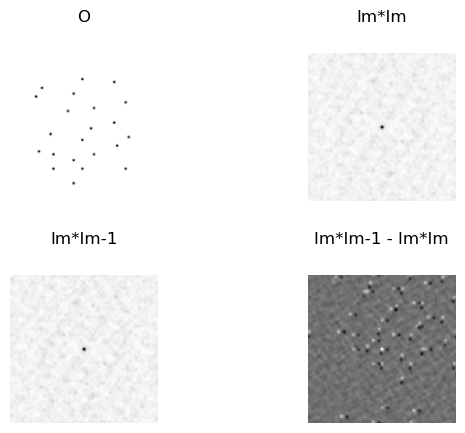

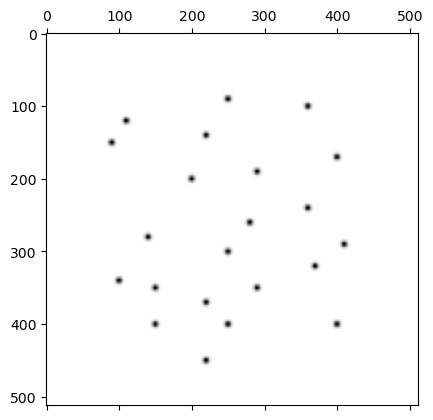

In [16]:
# Animation
#objects = backobjects.copy()

fig, ((ax1, ax2), (ax3, ax4))  = py.subplots(2,2)
ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax4.set_axis_off()
ax1.set_title("O")
ax2.set_title("Im*Im")
ax3.set_title("Im*Im-1")
ax4.set_title("Im*Im-1 - Im*Im")

filenames = []
for i in range(noframes):
    if i > 0:
        if i < (noframes-1):
            objects = backobjects.copy()
            objects += GaussPoint((xframeCirc[i],yframeCirc[i]),3)
            objects += GaussPoint((xframeCurve[i],yframeCurve[i]),3)
        else:
            objects = backobjects.copy()
            objects += GaussPoint((xframeCirc[0],yframeCirc[0]),3)
            objects += GaussPoint((xframeCurve[0],yframeCurve[0]),3)
            
        ax1.matshow(objects, cmap="binary")

        Cframeconvolution = np.fft.ifft2(np.fft.fft2(objects)*np.fft.fft2(Fspeckle))
        Cframeautocorrelation = np.fft.ifft2(np.fft.fft2(Cframeconvolution-mean)*np.conjugate(np.fft.fft2(Cframeconvolution-mean)))
        #print("Convolution")
        
        Pframeconvolution = np.fft.ifft2(np.fft.fft2(Pobjects)*np.fft.fft2(Fspeckle))
        Pframeautocorrelation = np.fft.ifft2(np.fft.fft2(Cframeconvolution-mean)*np.conjugate(np.fft.fft2(Pframeconvolution-mean)))
        #print("PConvolution")
        
        Delautocorrelation = Pframeautocorrelation - Cframeautocorrelation
        #print("DConvolution")
        
        Cframeautocorrelation = shift(Cframeautocorrelation)
        ax2.matshow(np.real(Cframeautocorrelation), cmap="binary")
        #print("shift1")
        
        Pframeautocorrelation = shift(Pframeautocorrelation)
        ax3.matshow(np.real(Pframeautocorrelation), cmap="binary")
        #print("hift2")
        
        Delautocorrelation = shift(Delautocorrelation)
        ax4.matshow(np.real(Delautocorrelation), cmap="binary")
        #print("shift3")
        
        
        py.subplots_adjust(wspace=0.5, hspace=0.5)
        py.savefig("Frame" + str(i) + ".png", format="png")
        filenames.append(image.imread("Frame" + str(i) + ".png"))
        Pobjects = objects.copy()
        print("Frame" + str(i))
            #ani.ArtistAnimation.new_frame_seq(objects)
            #py.matshow(objects, fignum=None, cmap="binary")
            #py.savefig("CurveObject" + str(i) + ".png", format="png")
            #filenames.append(image.imread("CurveObject" + str(i) + ".png"))
    else:
        objects = backobjects.copy()
        objects += GaussPoint((xframeCirc[0],yframeCirc[0]),3)
        objects += GaussPoint((xframeCurve[0],yframeCurve[0]),3)
        Pobjects = objects.copy()
            
image.imwrite("TwoMovingObjects.gif", filenames, duration=50, loop=0)
py.matshow(objects, fignum=None, cmap="binary") # Plot objects

#py.savefig("2MovingObjects.pdf", format="pdf")